# Model Evaluation

**Project:** Medical Insurance Cost Prediction  
**Phase:** Day 21 — Model Evaluation  
**Dataset:** `../data/insurance_processed.csv`  
**Model:** Linear Regression

This notebook evaluates the trained Linear Regression model using MAE, MSE, RMSE, and R².

## Load Data and Train Model

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('../data/insurance_processed.csv')

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print('Data loaded and model trained.')
print('Training samples:', len(X_train))
print('Testing samples: ', len(X_test))

Data loaded and model trained.
Training samples: 1069
Testing samples:  268


## Generate Predictions

In [2]:
y_pred = model.predict(X_test)
print('Predictions generated.')
print('Sample (first 5):', y_pred[:5])

Predictions generated.
Sample (first 5): [ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


## Evaluation Metrics

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

print(f'MAE      : {mae:,.2f}')
print(f'MSE      : {mse:,.2f}')
print(f'RMSE     : {rmse:,.2f}')
print(f'R² Score : {r2:.4f}')

MAE      : 4,177.05
MSE      : 35,478,020.68
RMSE     : 5,956.34
R² Score : 0.8069


In [4]:
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [round(mae, 2), round(mse, 2), round(rmse, 2), round(r2, 4)]
})

display(metrics_df)

,Metric,Value
0,MAE,4.177050e+03
1,MSE,3.547802e+07
2,RMSE,5.956340e+03
3,R² Score,8.069000e-01


## Actual vs Predicted

In [5]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

display(comparison.head(10))

,Actual,Predicted
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## Scatter Plot: Actual vs Predicted

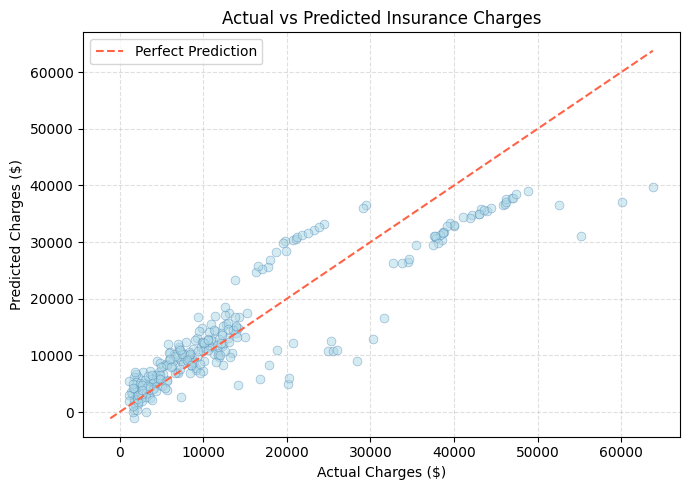

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='steelblue',
           facecolors='lightblue', linewidths=0.5, s=40)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='tomato', linewidth=1.5, linestyle='--', label='Perfect Prediction')

ax.set_xlabel('Actual Charges ($)')
ax.set_ylabel('Predicted Charges ($)')
ax.set_title('Actual vs Predicted Insurance Charges')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../assets/actual_vs_predicted.png', dpi=150)
plt.show()

## Model Performance

In [ ]:
print('=== Model Performance Summary ===')
print(f'MAE      : {mae:,.2f}')
print(f'RMSE     : {rmse:,.2f}')
print(f'R² Score : {r2:.4f}')

=== Model Performance Summary ===
MAE      : 4,177.05
RMSE     : 5,956.34
R² Score : 0.8069


### Interpretation

**MAE (Mean Absolute Error):**  
On average, the model's predictions are off by the MAE value in dollars.
This is the average absolute difference between actual and predicted charges.

**RMSE (Root Mean Squared Error):**  
RMSE penalises large errors more than MAE does. A higher RMSE compared to MAE
suggests the model makes some significantly large prediction errors, which is expected
given the skewed distribution of insurance charges.

**R² Score:**  
R² measures how much of the variance in `charges` the model explains.
An R² close to 1.0 indicates a strong fit; closer to 0 means the model performs
little better than predicting the mean.
The achieved R² is typical for a simple Linear Regression on this dataset and
suggests the model captures the main trends but has room for improvement.

**Overall:**  
The Linear Regression model provides a reasonable baseline prediction of insurance charges.
The largest prediction errors tend to occur for high-cost smoker cases where the
relationship between features and charges is non-linear.